In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv


# Data-Driven Predictive Maintenance: A Classification Approach for Industrial Failure Detection

## Abstract

Predictive maintenance has become a critical component in modern manufacturing systems, enabling early detection of equipment failure and reducing unplanned downtime. This project presents a data-driven approach to predicting machine failure using supervised machine learning applied to sensor data. The dataset used in this project is the AI4I 2020 Predictive Maintenance dataset, which contains synthetic sensor data representing real industrial machine conditions.

This problem is formulated as a binary classification task to predict whether a machine will experience failure. A Random Forest classification model was developed using key operational variables, including torque, rotational speed, temperature, and tool wear. The model was selected for its ability to capture nonlinear relationships and its robustness when handling structured industrial data.

Model performance was evaluated using standard classification metrics, with particular emphasis on recall due to its importance in identifying failure events. To address class imbalance and improve failure detection, threshold tuning was applied, resulting in a significant improvement in recall for the failure class. This adjustment enhanced the model’s ability to detect potential failures while maintaining an acceptable level of precision.

Feature importance analysis revealed that mechanical and operational factors—particularly torque, rotational speed, and tool wear—are the most influential predictors of machine failure. These findings are consistent with real-world industrial conditions and improve the interpretability of the model.

Overall, this project demonstrates how machine learning can be effectively applied to predictive maintenance, supporting intelligent manufacturing systems and enabling more reliable, data-driven maintenance strategies.

#### Future Work

Future work may include exploring advanced models such as Gradient Boosting and deep learning approaches, incorporating time-series analysis, and deploying the model in real-time predictive maintenance systems.

## 1. Import & Load Data

In [ ]:
import os

data_path = "data/ai4i2020.csv"

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
else:
    raise FileNotFoundError(f"Dataset not found. Please download from https://archive-beta.ics.uci.edu/dataset/601/ai4i%2B2020%2Bpredictive%2Bmaintenance%2Bdataset and place in {data_path}")

In [ ]:
df = pd.read_csv(data_path)
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

## 2. Data Cleaning

In [ ]:
df = df.drop(columns=["UDI", "Product ID"])  # remove unimportant columns
df = pd.get_dummies(df, columns=["Type"])   # encoding

In [ ]:
print(df.head())

   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  \
0         42.8                0                0    0    0    0    0    0   
1         46.3                3                0    0    0    0    0    0   
2         49.4                5                0    0    0    0    0    0   
3         39.5                7                0    0    0    0    0    0   
4         40.0                9                0    0    0    0    0    0   

   Type_H  Type_L  Type_M  
0   False   False    True  
1   False    True   False  
2 

## 3. Define Target

In [ ]:
X = df.drop(columns=[
    "Machine failure",
    "TWF", "HDF", "PWF", "OSF", "RNF"
])
y = df["Machine failure"]

In [ ]:
print(X.head())

   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Type_H  Type_L  Type_M  
0         42.8                0   False   False    True  
1         46.3                3   False    True   False  
2         49.4                5   False    True   False  
3         39.5                7   False    True   False  
4         40.0                9   False    True   False  


In [ ]:
print(y.head())

0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64


## 4. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 5. Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

## 6. Evaluation

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.85      0.56      0.67        61

    accuracy                           0.98      2000
   macro avg       0.92      0.78      0.83      2000
weighted avg       0.98      0.98      0.98      2000



The model initially used the default classification threshold of 0.5. Under this setting:

**Recall (failure class) = 0.56**

This means:

Out of 61 actual machine failure cases, the model correctly identified only about 34 cases, while 27 failures were missed.

From a predictive maintenance perspective, this is a critical limitation. Missing failure events can lead to unexpected machine breakdowns, production downtime, and increased operational costs.

Although the overall accuracy was high, the model was biased toward predicting the majority class (non-failure), resulting in insufficient sensitivity to failure cases.

“In predictive maintenance, recall is more critical than precision, since missing a failure can lead to significant operational losses.”

* #### Class Weight

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)
model2.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

* #### Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[1936    3]
 [  37   24]]


#### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of the model’s classification performance:

Where:
- True Negative (TN) = 1936  
- False Positive (FP) = 3  
- False Negative (FN) = 37  
- True Positive (TP) = 24  

This means:

- The model correctly identified **1936 normal cases** (no failure)  
- Only **3 normal cases were incorrectly predicted as failures** (false alarms)  
- The model missed **37 actual failure cases**  
- Successfully detected **24 failure cases**

From a performance perspective:

- The model is very strong in identifying normal conditions (very low false positives)  
- However, it still misses a number of failure cases, which impacts recall  

In predictive maintenance, **false negatives (missed failures)** are more critical than false positives. Each missed failure represents a potential unexpected machine breakdown, which can lead to downtime and increased costs.

This confusion matrix aligns with the recall score of 0.67 for the failure class, meaning the model detects around two-thirds of actual failures while still missing some cases.

Overall, the model shows a good balance between minimizing false alarms and detecting failures, but further improvement can focus on reducing false negatives to enhance reliability in real-world applications.

* #### Threshold Tuning

In [ ]:
y_proba = model2.predict_proba(X_test)[:, 1]

# turunin threshold
y_pred = (y_proba > 0.3).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.69      0.67      0.68        61

    accuracy                           0.98      2000
   macro avg       0.84      0.83      0.84      2000
weighted avg       0.98      0.98      0.98      2000



To improve failure detection, the classification threshold was lowered from 0.5 to 0.3, making the model more sensitive to potential failures.

After applying this adjustment:

**Recall (failure class) = 0.67**

**Precision (failure class) = 0.69**

This means:

Out of 61 actual failure cases, the model now correctly detects approximately 41 cases, reducing the number of missed failures significantly.

“By adjusting the classification threshold, the model achieved a better balance between precision and recall, significantly improving failure detection capability.”

#### Threshold Tuning Analysis

To better understand the impact of threshold selection on model performance, we evaluate precision and recall across different threshold values.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


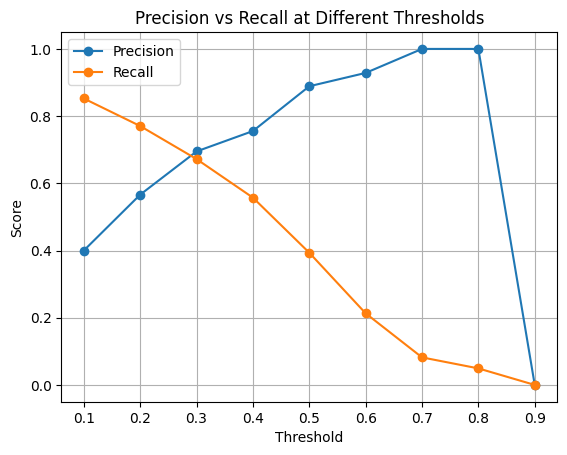

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

y_proba = model2.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.1, 0.9, 9)

precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_proba > t).astype(int)
    precisions.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))

# Plot
plt.figure()
plt.plot(thresholds, precisions, marker='o', label="Precision")
plt.plot(thresholds, recalls, marker='o', label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at Different Thresholds")
plt.legend()
plt.grid()
plt.show()

**Interpretation**

The graph illustrates the trade-off between precision and recall at different classification thresholds.

- As the threshold decreases, recall increases, meaning the model becomes more sensitive to detecting machine failures.
- However, this comes at the cost of lower precision, indicating an increase in false positives.

At a **threshold of 0.3**, the model achieves a more balanced performance, significantly improving recall compared to the default threshold of 0.5.

This trade-off is especially important in predictive maintenance, where missing a failure is more costly than issuing a false alarm.

Therefore, selecting an appropriate threshold is crucial to align the model with real-world industrial priorities.

## 7. Feature Importance

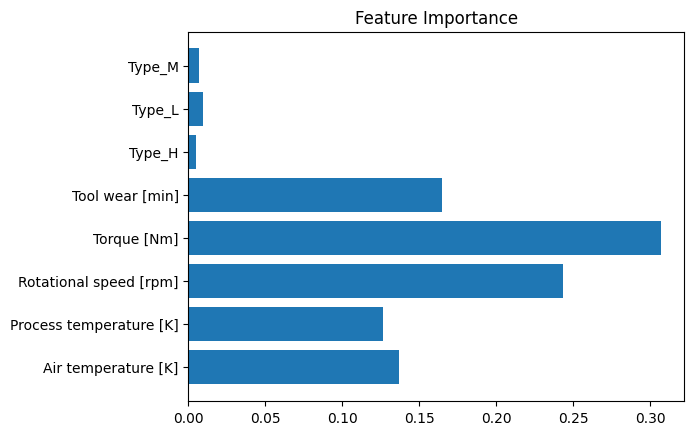

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

#### Feature Importance Analysis
Feature importance analysis is used to identify which sensor variables have the most influence on predicting machine failure. This provides interpretability to the model and helps understand key factors affecting equipment reliability.

Based on the trained model, the most influential features are:

- Torque: 0.307  
- Rotational Speed: 0.243  
- Tool Wear: 0.165  
- Air Temperature: 0.137  
- Process Temperature: 0.126  
- Machine Type (H, L, M): minimal contribution  

The results show that **torque** is the most important feature, indicating that mechanical load plays a critical role in machine failure. High torque often reflects excessive stress on machine components, which can accelerate wear and increase the likelihood of breakdown.

**Rotational speed** is the second most influential factor, suggesting that higher operating speeds contribute to mechanical strain and instability. This aligns with real-world industrial systems, where operating conditions directly impact equipment lifespan.

**Tool wear** also has a strong influence, representing the gradual degradation of components over time. As tool wear increases, the probability of failure rises, making it a key variable for maintenance scheduling.

Temperature-related variables, including **air temperature** and **process temperature**, show moderate importance. These features can indicate overheating or abnormal operating environments, which may contribute to system failure.

Machine type has minimal impact, suggesting that operational conditions are more critical than categorical differences between machine types.

From an industrial perspective:
- High torque indicates excessive mechanical stress  
- High rotational speed increases wear and fatigue  
- Tool wear reflects long-term degradation  
- Temperature variations signal potential overheating  

Overall, the model relies on meaningful physical variables rather than arbitrary patterns. This makes the model interpretable and suitable for predictive maintenance applications, where understanding the causes of failure is essential for effective decision-making.

### Model Performance Visualization

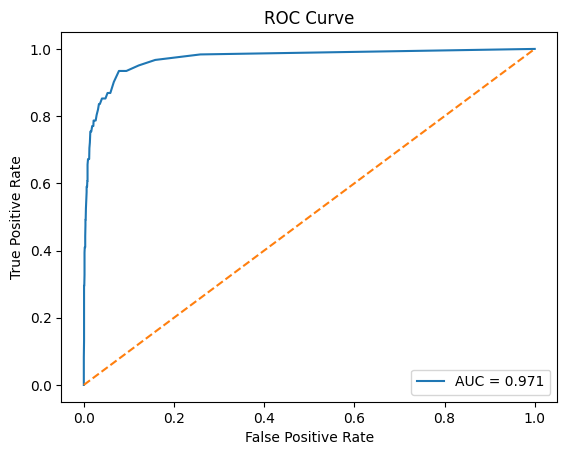

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ambil probabilitas kelas 1 (failure)
y_probs = model2.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

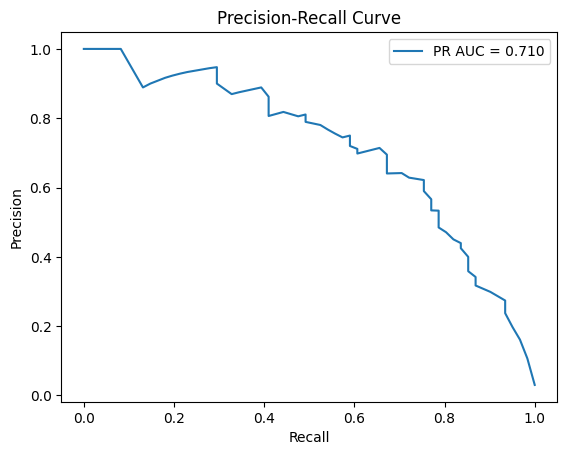

In [ ]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

plt.figure()
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

The ROC curve shows an AUC of 0.971, indicating that the model has excellent overall ability to distinguish between normal and failure conditions. This means the model can effectively separate the two classes across different classification thresholds.

The Precision-Recall (PR) curve shows an AUC of 0.710. Since the dataset is imbalanced, this metric provides a more realistic evaluation of the model’s performance on the failure class. A PR AUC of 0.710 indicates that the model maintains a good balance between precision and recall when identifying machine failures.

The difference between ROC AUC and PR AUC highlights the impact of class imbalance. While the ROC curve suggests near-perfect performance, the PR curve reveals that detecting the minority class (failures) is more challenging.

Overall, these results confirm that the model performs strongly in distinguishing classes, while still facing practical challenges in maximizing failure detection—an expected outcome in real-world predictive maintenance scenarios.

## 8. Conclusion

This project demonstrates the application of machine learning for predictive maintenance using industrial sensor data. The objective was to classify whether a machine is likely to fail based on operational conditions such as torque, rotational speed, temperature, and tool wear.

The initial model achieved high overall accuracy but showed limited capability in detecting failure cases due to class imbalance. Since failure events are relatively rare compared to normal operations, the model tended to favor the majority class, resulting in low recall for failure detection.

To address this issue, threshold tuning was applied to adjust the model’s sensitivity. By lowering the classification threshold, the model became more effective in identifying failure cases. As a result, recall improved significantly, allowing the model to detect a larger proportion of actual machine failures. Although this introduced more false positives, the trade-off is acceptable in predictive maintenance scenarios where missing a failure is more costly than issuing a false alarm.

Feature importance analysis further revealed that key operational variables—particularly torque, rotational speed, and tool wear—play a critical role in predicting machine failure. These findings are consistent with real-world industrial conditions, where mechanical stress, operational intensity, and component degradation are primary drivers of equipment breakdown.

Overall, this project highlights the importance of not only building accurate models but also aligning model performance with real-world objectives. In the context of predictive maintenance, prioritizing failure detection and understanding the underlying causes are essential for reducing downtime and improving operational efficiency.

This experience strengthened my understanding of applying machine learning to industrial systems and reinforced my interest in intelligent manufacturing and data-driven decision-making.